## Variational Autoencoder

In [171]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset, Subset
import matplotlib.pyplot as plt
import os
import numpy as np
from torchvision.utils import save_image, make_grid
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from IPython.core.magic import register_cell_magic
from tqdm import tqdm

In [172]:
@register_cell_magic
def skip(line, cell):
    """Skips the cell if 'True' or no argument is passed."""
    if not line or line.lower() == 'true':
        return
    get_ipython().run_cell(cell)

### Linear MNIST VAE

In [173]:
class MNIST_LinearVAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(MNIST_LinearVAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 400),
            nn.ReLU(),
            nn.Linear(400, 128),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 400),
            nn.ReLU(),
            nn.Linear(400, 784),
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x)
        mu, logvar = self.fc_mu(h), self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z).view(-1, 1, 28, 28), mu, logvar

### Convolutional MNIST VAE

In [174]:
class MNIST_ConvVAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(MNIST_ConvVAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1), # 14x14
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), # 7x7
            nn.ReLU(),
            nn.Flatten()
        )
        self.fc_mu = nn.Linear(64 * 7 * 7, latent_dim)
        self.fc_logvar = nn.Linear(64 * 7 * 7, latent_dim)
        
        self.decoder_input = nn.Linear(latent_dim, 64 * 7 * 7)
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (64, 7, 7)),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x)
        mu, logvar = self.fc_mu(h), self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)
        return self.decoder(self.decoder_input(z)), mu, logvar

### Linear MNIST AE

In [175]:
class MNIST_LinearAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(MNIST_LinearAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z).view(-1, 1, 28, 28), z

### Convolutional MNIST AE

In [176]:
class MNIST_ConvAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(MNIST_ConvAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1), # 14x14
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), # 7x7
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32 * 7 * 7),
            nn.Unflatten(1, (32, 7, 7)),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

In [177]:
def vae_loss_function(recon_x, x, mu, logvar, beta=0.1):
    # use Mean squared error as reconstruction loss
    mse = F.mse_loss(recon_x, x, reduction='sum')
    # print(f"MSE: {mse}")
    
    # use KL divergence for privacy preserving distribution
    kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    # print(f"KLD: {kld_loss}")
    
    return mse + (beta * kld_loss)

In [178]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transform = transforms.Compose([
    transforms.ToTensor(), # scaled to [0, 1] automatically
    # transforms.RandomRotation(10), # Optional: helps local VAEs generalize better
    transforms.Normalize((0.1307,), (0.3081,)) 
])
# save_path = "models/conv_heavy_vae_cifar10.pth"

In [179]:
train_set = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_set = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

In [180]:
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = DataLoader(test_set, batch_size=1000, shuffle=False)

In [181]:
# vae_linear = MNIST_LinearVAE(latent_dim=256)
vae_conv = MNIST_ConvVAE(latent_dim=256).to(device)
epochs = 1

### Training

In [182]:
optimizer = optim.Adam(vae_conv.parameters(), lr=1e-3)

vae_conv.train()
for epoch in range(epochs):
    total_loss = 0
    for images, _ in tqdm(train_loader):
        images = images.to(device) # No more flattening needed for ConvVAE!
        
        optimizer.zero_grad()
        
        # Unpack the three outputs from your new forward method
        recon_batch, mu, logvar = vae_conv(images)
        
        # Use thes specialized VAE loss function
        loss = vae_loss_function(recon_batch, images, mu, logvar, beta=0.1)
        total_loss += loss.item()
        loss.backward()
        optimizer.step()
    print(f"Epoch: {epoch+1}, Loss: {total_loss:.2f}")

100%|██████████| 938/938 [00:25<00:00, 36.36it/s]

Epoch: 1, Loss: 25621559.43


### Reconstruction

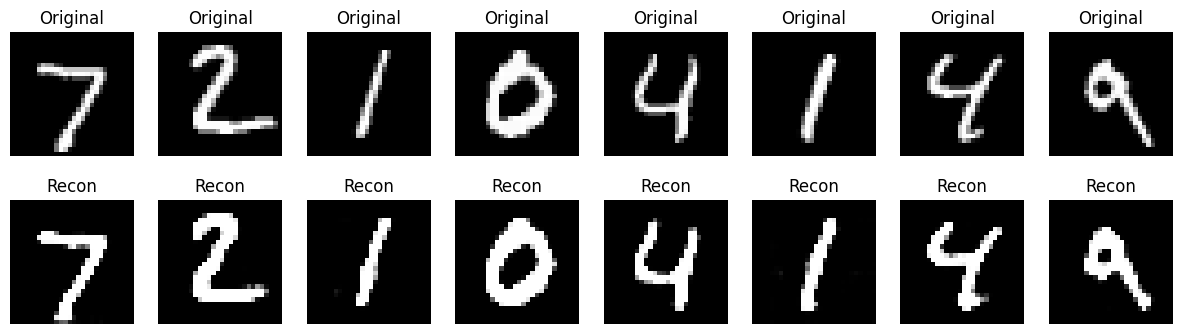

In [183]:
def visualize_reconstructions(model, test_loader, device, n=8):
    model.eval()
    with torch.no_grad():
        # Get a sample batch
        data, _ = next(iter(test_loader))
        data = data.to(device)
        
        outputs = model(data)
        recon = outputs[0] # First element is always the reconstruction
        
        data = data.cpu()
        recon = recon.cpu()
        
        plt.figure(figsize=(15, 4))
        for i in range(n):
            # Original
            ax = plt.subplot(2, n, i + 1)
            plt.imshow(data[i].squeeze(), cmap='gray')
            plt.title("Original")
            plt.axis('off')
            
            # Reconstruction
            ax = plt.subplot(2, n, i + 1 + n)
            plt.imshow(recon[i].squeeze(), cmap='gray')
            plt.title("Recon")
            plt.axis('off')
        plt.show()

visualize_reconstructions(vae_conv, test_loader, device)

In [184]:
def generate_latent_soup_dataset(vae, dataloader, device, k=2, num_samples=5000):
    vae.eval()
    soup_images = []
    soup_labels = []
    
    # Pre-fetch all images from the loader for easy random sampling
    all_imgs = []
    all_lbls = []
    for imgs, lbls in dataloader:
        all_imgs.append(imgs)
        all_lbls.append(lbls)
    all_imgs = torch.cat(all_imgs).to(device)
    all_lbls = torch.cat(all_lbls).to(device)

    with torch.no_grad():
        for _ in range(num_samples):
            # 1. Pick k random indices
            idx = torch.randint(0, len(all_imgs), (k,))
            subset_imgs = all_imgs[idx]
            subset_lbls = all_lbls[idx]
            
            # 2. Encode to Latent Space
            mu, logvar = vae.encoder(subset_imgs), None # Simplified for speed
            # Note: For VAE, use the mu (mean) as the stable representation
            if hasattr(vae, 'fc_mu'): # Handling our ConvVAE structure
                h = vae.encoder(subset_imgs)
                z_mu = vae.fc_mu(h)
            else:
                z_mu = vae.encoder(subset_imgs.view(k, -1)) # For Linear VAE
            
            # 3. Create the "Soup" (Average the latent vectors)
            z_soup = torch.mean(z_mu, dim=0, keepdim=True)
            
            # 4. Decode the Soup back to an image
            if hasattr(vae, 'decoder_input'):
                ghost_img = vae.decoder(vae.decoder_input(z_soup))
            else:
                ghost_img = vae.decoder(z_soup)
            
            # 5. Create the Soft Label (One-hot average)
            soft_label = torch.zeros(10).to(device)
            for lbl in subset_lbls:
                soft_label[lbl] += 1.0 / k
                
            soup_images.append(ghost_img.cpu())
            soup_labels.append(soft_label.cpu())
            
    return torch.cat(soup_images), torch.stack(soup_labels)

In [185]:
class MNIST_Classifier(nn.Module):
    def __init__(self):
        super(MNIST_Classifier, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, 1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(9216, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.conv(x)

In [186]:
num_samples = 5000
fair_indices = torch.randperm(len(train_set))[:num_samples]
fair_normal_dataset = Subset(train_set, fair_indices)

# 3. Create the loader
train_loader = DataLoader(fair_normal_dataset, batch_size=64, shuffle=True)

# --- Step 1: Generate the Soup Data ---
# Use the trained Conv_VAE from the previous step
soup_imgs, soup_lbls = generate_latent_soup_dataset(vae_conv, train_loader, device, k=2, num_samples=num_samples)
soup_dataset = TensorDataset(soup_imgs, soup_lbls)
soup_loader = DataLoader(soup_dataset, batch_size=64, shuffle=True)

# --- Step 2: Training Function (Handles Soft or Hard Labels) ---
def train_classifier(model, loader, device, is_soup=False):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.BCEWithLogitsLoss() if is_soup else nn.CrossEntropyLoss()
    model.train()
    
    for epoch in range(5): # MNIST trains very fast
        for imgs, lbls in tqdm(loader):
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            output = model(imgs)
            loss = criterion(output, lbls)
            loss.backward()
            optimizer.step()
    return model

# --- Step 3: Run the Comparison ---
print("Training Normal Model on Real Data...")
normal_cnn = MNIST_Classifier().to(device)
train_classifier(normal_cnn, train_loader, device, is_soup=False)

print("Training Privacy Model on Latent Soups...")
soup_cnn = MNIST_Classifier().to(device)
train_classifier(soup_cnn, soup_loader, device, is_soup=True)

# --- Step 4: Final Test Accuracy ---
def evaluate(model, test_loader, name):
    model.eval()
    correct = 0
    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            pred = model(imgs).argmax(dim=1)
            correct += (pred == lbls).sum().item()
    print(f"{name} Test Accuracy: {100. * correct / len(test_loader.dataset):.2f}%")

evaluate(normal_cnn, test_loader, "Normal Model")
evaluate(soup_cnn, test_loader, "Soup Model")

Training Normal Model on Real Data...


100%|██████████| 79/79 [00:03<00:00, 26.08it/s]


Training Privacy Model on Latent Soups...


100%|██████████| 79/79 [00:02<00:00, 31.68it/s]


Normal Model Test Accuracy: 97.31%
Soup Model Test Accuracy: 92.67%


In [192]:
soup_imgs, soup_lbls = generate_latent_soup_dataset(vae_conv, train_loader, device, k=20, num_samples=num_samples)
soup_loader = DataLoader(soup_dataset, batch_size=64, shuffle=True)
blended_images, blended_labels = next(iter(soup_loader))

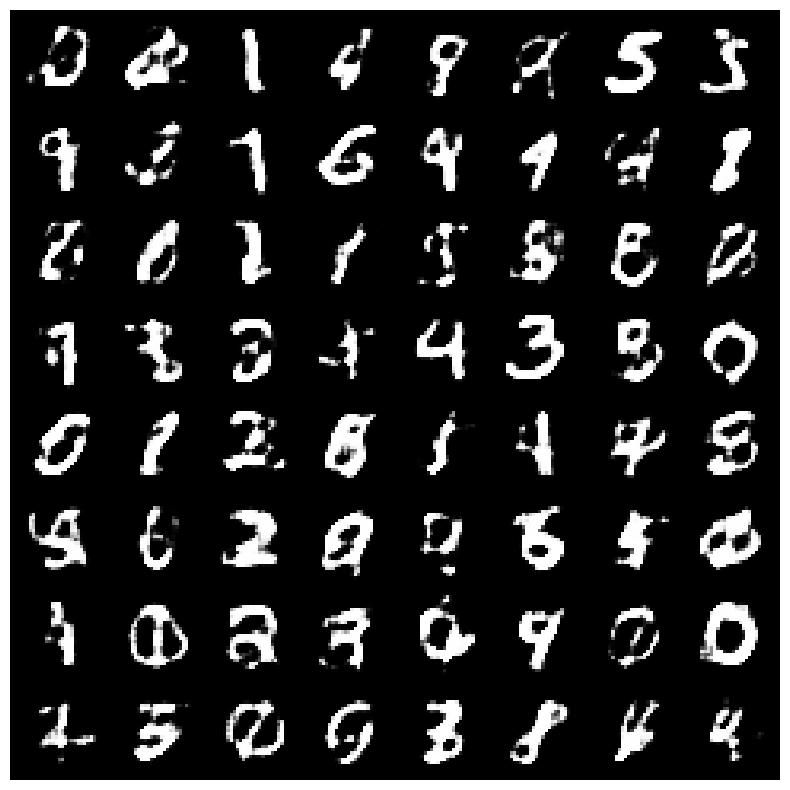

In [193]:
blended_grid = make_grid(blended_images, nrow=8)
plt.figure(figsize=(10, 10))
plt.imshow(blended_grid.permute(1, 2, 0).cpu().numpy())
plt.axis('off')
plt.show()